Smart Ad Budget Allocator

Imagine you are leading marketing at a company. You spend money across two advertising channels: **TV**, and **Radio**.

Your goal is to figure out:
1. Which ad channel actually drives sales, and which one is wasting money?


Quick Background: How Linear Regression Works
We want to build a simple formula:

$$\text{Sales} = \beta_0 + (\beta_{\text{TV}} \times \text{TV Spend}) + (\beta_{\text{Radio}} \times \text{Radio Spend}) $$

* **$\beta_0$ (Baseline Sales):** Sales you get even if you spend \$0 on ads.
* **$\beta_{\text{TV}}, \beta_{\text{Radio}}$:** How much extra sales you get for every \$1,000 spent on that channel.

Instead of guessing, linear algebra gives us the best possible values in one exact calculation:

$$\beta = (X^T X)^{-1} X^T y$$


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Marketing Campaign Dataset
X_spend = np.array([
    [230.1,  37.8],
    [ 44.5,  39.3], 
    [ 17.2,  45.9], 
    [151.5,  41.3],
    [180.8,  10.8], 
    [  8.7,  48.9], 
    [ 57.5,  32.8], 
    [120.2,  19.6],
    [  8.6,   2.1], 
    [199.8,   2.6], 
    [ 66.1,   5.8], 
    [214.7,  24.0],
    [ 23.8,  35.1], 
    [ 97.5,   7.6], 
    [204.1,  32.9], 
    [195.4,  47.7],
    [ 67.8,  36.6], 
    [281.4,  39.6], 
    [ 69.2,  20.5], 
    [147.3,  23.9]
])

y_sales = np.array([
    22.1, 10.4,  9.3, 18.5, 12.9,  7.2, 11.8, 13.2,  4.8, 10.6,
     8.6, 17.4,  9.2,  9.7, 19.0, 22.4, 12.5, 24.4, 11.3, 14.6
])

df = pd.DataFrame({
    'TV (in $1000s)': X_spend[:, 0],
    'Radio (in $1000s)': X_spend[:, 1],
    'Sales (in 1000 units)': y_sales
})

print(df.head(4))

tv = df['TV (in $1000s)']
radio = df['Radio (in $1000s)']
sales = df['Sales (in 1000 units)']



   TV (in $1000s)  Radio (in $1000s)  Sales (in 1000 units)
0           230.1               37.8                   22.1
1            44.5               39.3                   10.4
2            17.2               45.9                    9.3
3           151.5               41.3                   18.5


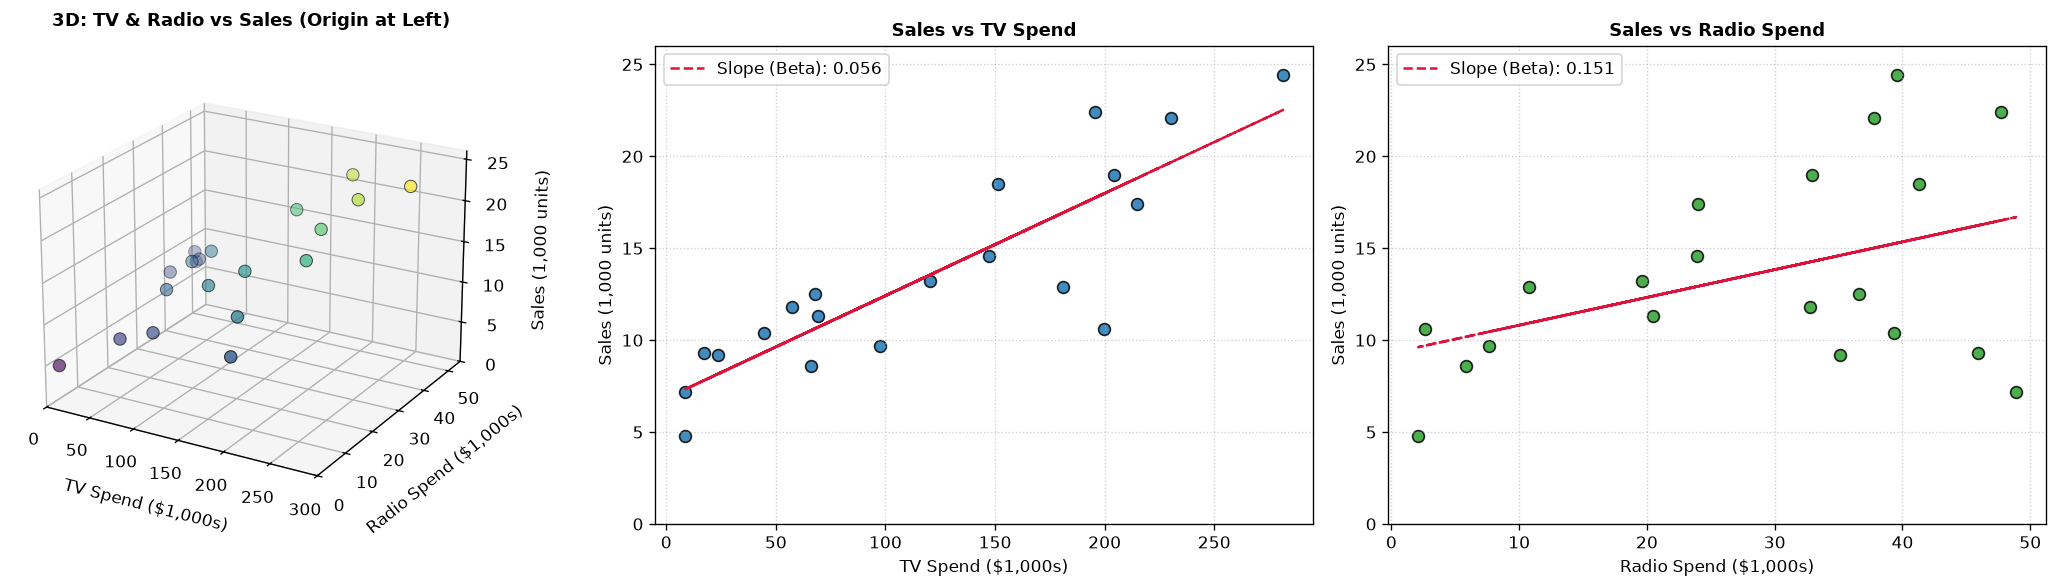

In [47]:
fig = plt.figure(figsize=(18, 5), dpi=120)

# Subplot 1: 3D Scatter
ax1 = fig.add_subplot(131, projection='3d')
scatter = ax1.scatter(
    tv, radio, sales,
    c=sales, cmap='viridis',
    s=55, edgecolor='k', linewidth=0.6, alpha=0.9
)
ax1.set_title("3D: TV & Radio vs Sales (Origin at Left)", fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel("TV Spend ($1,000s)", labelpad=8)
ax1.set_ylabel("Radio Spend ($1,000s)", labelpad=8)
ax1.set_zlabel("Sales (1,000 units)", labelpad=8)
ax1.set_xlim(0, 300)
ax1.set_ylim(0, 55)
ax1.set_zlim(0, 26)
ax1.view_init(elev=22, azim=-60)

# Subplot 2: 2D TV Spend vs Sales
ax2 = fig.add_subplot(132)
ax2.scatter(tv, sales, color='#1f77b4', edgecolors='k', s=50, alpha=0.85)
m_tv, b_tv = np.polyfit(tv, sales, 1)
ax2.plot(tv, m_tv * tv + b_tv, color='crimson', linestyle='--', label=f'Slope (Beta): {m_tv:.3f}')
ax2.set_title("Sales vs TV Spend", fontsize=11, fontweight='bold')
ax2.set_xlabel("TV Spend ($1,000s)")
ax2.set_ylabel("Sales (1,000 units)")
ax2.set_ylim(0, 26)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

# Subplot 3: 2D Radio Spend vs Sales
ax3 = fig.add_subplot(133)
ax3.scatter(radio, sales, color='#2ca02c', edgecolors='k', s=50, alpha=0.85)
m_rad, b_rad = np.polyfit(radio, sales, 1)
ax3.plot(radio, m_rad * radio + b_rad, color='crimson', linestyle='--', label=f'Slope (Beta): {m_rad:.3f}')
ax3.set_title("Sales vs Radio Spend", fontsize=11, fontweight='bold')
ax3.set_xlabel("Radio Spend ($1,000s)")
ax3.set_ylabel("Sales (1,000 units)")
ax3.set_ylim(0, 26)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Finding Channel Returns

1. Add a column of 1s in front of your spend data so the model can calculate the baseline sales $\beta_0$.
2. Calculate $\beta = (X^T X)^{-1} X^T y$ using NumPy.
3. Check your prediction error using the Residual Sum of Squares (RSS): $\sum (\text{actual} - \text{predicted})^2$.

In [48]:
def analyze_campaigns(X, y):
    # 1. Add a column of 1s for the baseline intercept
    ones = np.ones((X.shape[0], 1))
    X_with_intercept = np.column_stack([ones, X])
    
    # 2. Formula: beta = (X^T * X)^(-1) * X^T * y
    
    Xt_X = X_with_intercept.T @ X_with_intercept
    Xt_y = X_with_intercept.T @ y
    beta = np.linalg.inv(Xt_X) @ Xt_y
    
    # 3. Calculate predicted sales and total error (RSS)
    predictions = X_with_intercept @ beta
    residuals = y - predictions
    rss = np.sum(residuals ** 2)
    
    return beta, rss

beta_values, total_error = analyze_campaigns(X_spend, y_sales)

print(f"Baseline Sales (Spend = $0): {beta_values[0]:.2f}k units")
print(f"TV Return (per $1k spent):    +{beta_values[1]:.3f}k units")
print(f"Radio Return (per $1k spent): +{beta_values[2]:.3f}k units")
print(f"Total Model Error (RSS):      {total_error:.2f}")

Baseline Sales (Spend = $0): 2.74k units
TV Return (per $1k spent):    +0.056k units
Radio Return (per $1k spent): +0.149k units
Total Model Error (RSS):      42.53


In [49]:
# --- Calculation of Predictions, Residuals, and Single-Variable Models ---
ones = np.ones((X_spend.shape[0], 1))
X_with_intercept = np.column_stack([ones, X_spend])
predictions = X_with_intercept @ beta_values
residuals = y_sales - predictions

# TV-alone model (simple regression)
X_tv = np.column_stack([ones, X_spend[:, 0]])
beta_tv = np.linalg.inv(X_tv.T @ X_tv) @ (X_tv.T @ y_sales)
pred_tv = X_tv @ beta_tv
res_tv = y_sales - pred_tv
rss_tv = np.sum(res_tv ** 2)

# Radio-alone model (simple regression)
X_radio = np.column_stack([ones, X_spend[:, 1]])
beta_radio = np.linalg.inv(X_radio.T @ X_radio) @ (X_radio.T @ y_sales)
pred_radio = X_radio @ beta_radio
res_radio = y_sales - pred_radio
rss_radio = np.sum(res_radio ** 2)

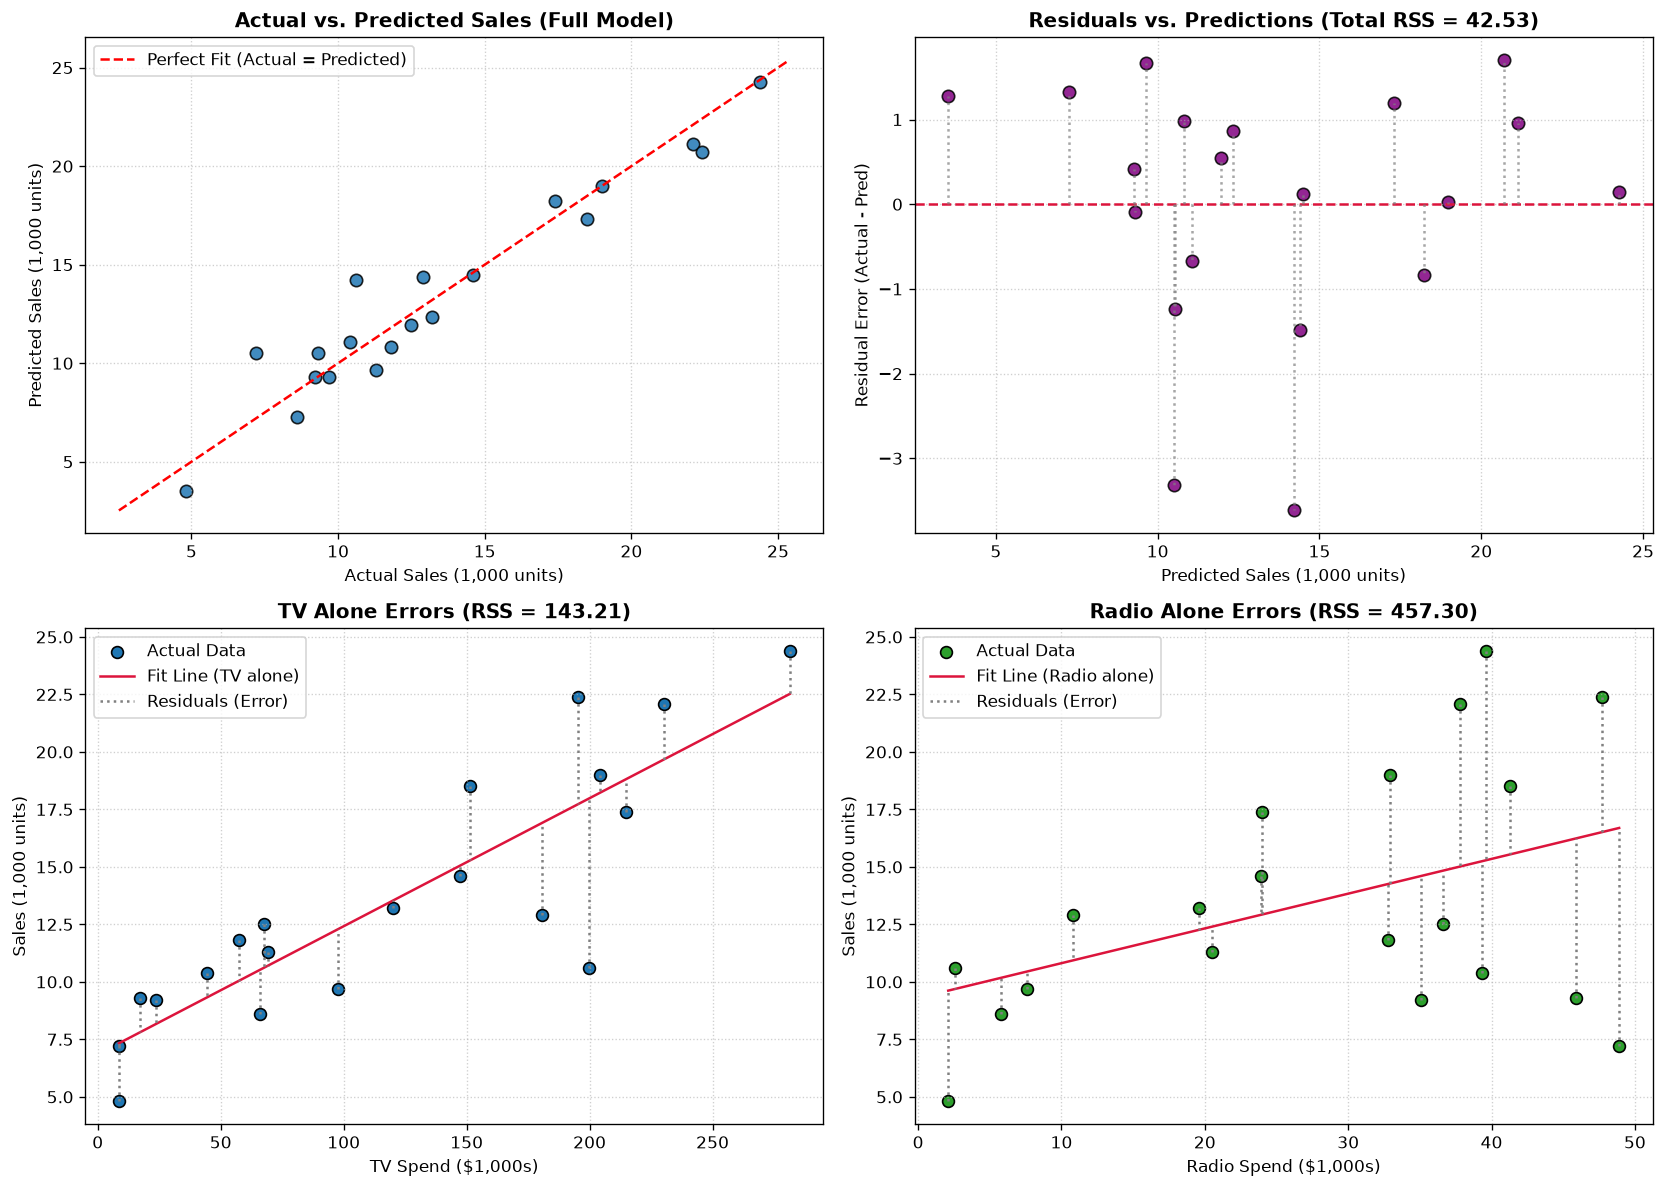

In [50]:

# --- Visualizations (2x2 Grid) ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

# Plot 1: Actual vs. Predicted Sales (Full Model)
axs[0, 0].scatter(y_sales, predictions, color='#1f77b4', edgecolors='k', s=55, alpha=0.85)
min_val = min(y_sales.min(), predictions.min()) - 1
max_val = max(y_sales.max(), predictions.max()) + 1
axs[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit (Actual = Predicted)')
axs[0, 0].set_title('Actual vs. Predicted Sales (Full Model)', fontweight='bold')
axs[0, 0].set_xlabel('Actual Sales (1,000 units)')
axs[0, 0].set_ylabel('Predicted Sales (1,000 units)')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Residuals / Error Plot (Full Model)
axs[0, 1].scatter(predictions, residuals, color='purple', edgecolors='k', s=55, alpha=0.85)
axs[0, 1].axhline(0, color='crimson', linestyle='--')
axs[0, 1].vlines(predictions, 0, residuals, colors='gray', linestyles=':', alpha=0.7)
axs[0, 1].set_title(f'Residuals vs. Predictions (Total RSS = {total_error:.2f})', fontweight='bold')
axs[0, 1].set_xlabel('Predicted Sales (1,000 units)')
axs[0, 1].set_ylabel('Residual Error (Actual - Pred)')
axs[0, 1].grid(True, linestyle=':', alpha=0.6)


# Plot 3: TV-Alone Error / Residual Distances
sorted_tv_idx = np.argsort(X_spend[:, 0])
tv_sorted = X_spend[:, 0][sorted_tv_idx]
pred_tv_sorted = pred_tv[sorted_tv_idx]

axs[1, 0].scatter(X_spend[:, 0], y_sales, color='#1f77b4', edgecolors='k', s=50, label='Actual Data')
axs[1, 0].plot(tv_sorted, pred_tv_sorted, color='crimson', label=f'Fit Line (TV alone)')
axs[1, 0].vlines(X_spend[:, 0], y_sales, pred_tv, colors='gray', linestyles=':', label='Residuals (Error)')
axs[1, 0].set_title(f'TV Alone Errors (RSS = {rss_tv:.2f})', fontweight='bold')
axs[1, 0].set_xlabel('TV Spend ($1,000s)')
axs[1, 0].set_ylabel('Sales (1,000 units)')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle=':', alpha=0.6)

# Plot 4: Radio-Alone Error / Residual Distances
sorted_rad_idx = np.argsort(X_spend[:, 1])
rad_sorted = X_spend[:, 1][sorted_rad_idx]
pred_rad_sorted = pred_radio[sorted_rad_idx]

axs[1, 1].scatter(X_spend[:, 1], y_sales, color='#2ca02c', edgecolors='k', s=50, label='Actual Data')
axs[1, 1].plot(rad_sorted, pred_rad_sorted, color='crimson', label=f'Fit Line (Radio alone)')
axs[1, 1].vlines(X_spend[:, 1], y_sales, pred_radio, colors='gray', linestyles=':', label='Residuals (Error)')
axs[1, 1].set_title(f'Radio Alone Errors (RSS = {rss_radio:.2f})', fontweight='bold')
axs[1, 1].set_xlabel('Radio Spend ($1,000s)')
axs[1, 1].set_ylabel('Sales (1,000 units)')
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()